#  cricket analysis project 

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### load dataset

In [61]:
df=pd.read_csv('1-cricket-data.csv',na_values=['-'])
df

,Player,Span,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,4s,6s
0,DG Bradman (AUS),1928-1948,52,80,10,6996,334,99.94,9800+,58.60,29,13,7.0,626+,6
1,PHKD Mendis (SL),2022-2025,12,21,2,1184,182*,62.31,1839,64.38,5,4,NaN,123,23
2,AC Voges (AUS),2015-2016,20,31,7,1485,269*,61.87,2667,55.68,5,4,2.0,186,5
3,RG Pollock (SA),1963-1970,23,41,4,2256,274,60.97,1707+,54.48,7,11,1.0,246+,11
4,GA Headley (WI),1930-1954,22,40,4,2190,270*,60.83,416+,56.00,10,5,2.0,104+,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57,KD Walters (AUS),1965-1981,74,125,14,5357,250,48.26,8662+,49.16,15,33,4.0,525+,23
58,GC Smith (ICC/SA),2002-2014,117,205,13,9265,277,48.25,15525,59.67,27,38,11.0,1165,24
59,WH Ponsford (AUS),1924-1934,29,48,4,2122,266,48.22,3118+,44.77,7,6,1.0,119+,0
60,SJ McCabe (AUS),1930-1938,39,62,5,2748,232,48.21,3217+,60.02,6,13,4.0,241+,5+


In [62]:
df.shape

(62, 15)

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Player  62 non-null     object 
 1   Span    62 non-null     object 
 2   Mat     62 non-null     int64  
 3   Inns    62 non-null     int64  
 4   NO      62 non-null     int64  
 5   Runs    62 non-null     int64  
 6   HS      62 non-null     object 
 7   Ave     62 non-null     float64
 8   BF      59 non-null     object 
 9   SR      59 non-null     float64
 10  100     62 non-null     int64  
 11  50      62 non-null     int64  
 12  0       61 non-null     float64
 13  4s      62 non-null     object 
 14  6s      62 non-null     object 
dtypes: float64(3), int64(6), object(6)
memory usage: 7.4+ KB


In [64]:
df.columns

Index(['Player', 'Span', 'Mat', 'Inns', 'NO', 'Runs', 'HS', 'Ave', 'BF', 'SR',
       '100', '50', '0', '4s', '6s'],
      dtype='object')

In [65]:
df.rename(columns={'Mat':'match','NO':'not out','HS':'highest strike','Ave':'Average','BF':'ball faced','SR':'strike rate'},inplace=True)

In [66]:
df.isna().sum()[df.isna().sum() > 0]

ball faced     3
strike rate    3
0              1
dtype: int64

In [87]:
df['ball faced']=df['ball faced'].fillna(0)
df['strike rate']=df['strike rate'].fillna(0)
df['0']=df['0'].fillna(0)

In [68]:
df.columns=df.columns.str.lower()

In [69]:
df.head(2)

,player,span,match,inns,not out,runs,highest strike,average,ball faced,strike rate,100,50,0,4s,6s
0,DG Bradman (AUS),1928-1948,52,80,10,6996,334,99.94,9800+,58.60,29,13,7.0,626+,6
1,PHKD Mendis (SL),2022-2025,12,21,2,1184,182*,62.31,1839,64.38,5,4,0.0,123,23


In [70]:
df.isna().sum()

player            0
span              0
match             0
inns              0
not out           0
runs              0
highest strike    0
average           0
ball faced        0
strike rate       0
100               0
50                0
0                 0
4s                0
6s                0
dtype: int64

In [71]:
df[['start date','end date']]=df['span'].str.split('-',expand=True)

In [72]:
df.drop(columns='span',inplace=True)

In [73]:
df.head()

,player,match,inns,not out,runs,highest strike,average,ball faced,strike rate,100,50,0,4s,6s,start date,end date
0,DG Bradman (AUS),52,80,10,6996,334,99.94,9800+,58.60,29,13,7.0,626+,6,1928,1948
1,PHKD Mendis (SL),12,21,2,1184,182*,62.31,1839,64.38,5,4,0.0,123,23,2022,2025
2,AC Voges (AUS),20,31,7,1485,269*,61.87,2667,55.68,5,4,2.0,186,5,2015,2016
3,RG Pollock (SA),23,41,4,2256,274,60.97,1707+,54.48,7,11,1.0,246+,11,1963,1970
4,GA Headley (WI),22,40,4,2190,270*,60.83,416+,56.00,10,5,2.0,104+,1,1930,1954


In [74]:
df['ball faced'].unique()

array(['9800+', '1839', '2667', '1707+', '416+', '6558+', '1288+',
       '4957+', 0, '2581', '7491+', '4063+', '22882', '5363+', '19176',
       '2844+', '28903', '178+', '17913', '665+', '1823', '13079+',
       '108+', '29437+', '19753', '2738', '15164+', '31258', '14372',
       '19375', '22782', '2035+', '10636', '12436', '27395', '14184+',
       '22461', '22568', '14349', '16077', '27002+', '3345', '9613+',
       '2731+', '22959', '16345', '488+', '619+', '10441', '2445',
       '15456', '885+', '158+', '11641', '1799+', '8662+', '15525',
       '3118+', '3217+', '2110+'], dtype=object)

In [75]:
df['ball faced']=df['ball faced'].str.replace('+',"")

In [76]:
df['highest strike']=df['highest strike'].str.replace('*','')

In [77]:
df['highest strike'].unique()

array(['334', '182', '269', '274', '270', '194', '243', '256', '207',
       '317', '336', '365', '319', '211', '239', '220', '364', '224',
       '122', '251', '183', '227', '247', '231', '248', '400', '214',
       '280', '223', '313', '257', '201', '232', '195', '203', '236',
       '200', '262', '380', '278', '205', '208', '291', '374', '329',
       '261', '215', '144', '189', '250', '277', '266', '127'],
      dtype=object)

In [78]:
df.columns.unique()

Index(['player', 'match', 'inns', 'not out', 'runs', 'highest strike',
       'average', 'ball faced', 'strike rate', '100', '50', '0', '4s', '6s',
       'start date', 'end date'],
      dtype='object')

In [79]:
df['4s']=df['4s'].str.replace('+','')
df['6s']=df['6s'].str.replace('+','')

In [80]:
df.head()

,player,match,inns,not out,runs,highest strike,average,ball faced,strike rate,100,50,0,4s,6s,start date,end date
0,DG Bradman (AUS),52,80,10,6996,334,99.94,9800,58.60,29,13,7.0,626,6,1928,1948
1,PHKD Mendis (SL),12,21,2,1184,182,62.31,1839,64.38,5,4,0.0,123,23,2022,2025
2,AC Voges (AUS),20,31,7,1485,269,61.87,2667,55.68,5,4,2.0,186,5,2015,2016
3,RG Pollock (SA),23,41,4,2256,274,60.97,1707,54.48,7,11,1.0,246,11,1963,1970
4,GA Headley (WI),22,40,4,2190,270,60.83,416,56.00,10,5,2.0,104,1,1930,1954


In [81]:
df[['player','country']]=df['player'].str.split('(',expand=True)

In [82]:
df['country']=df['country'].str.replace(')','')

In [83]:
df.head()

,player,match,inns,not out,runs,highest strike,average,ball faced,strike rate,100,50,0,4s,6s,start date,end date,country
0,DG Bradman,52,80,10,6996,334,99.94,9800,58.60,29,13,7.0,626,6,1928,1948,AUS
1,PHKD Mendis,12,21,2,1184,182,62.31,1839,64.38,5,4,0.0,123,23,2022,2025,SL
2,AC Voges,20,31,7,1485,269,61.87,2667,55.68,5,4,2.0,186,5,2015,2016,AUS
3,RG Pollock,23,41,4,2256,274,60.97,1707,54.48,7,11,1.0,246,11,1963,1970,SA
4,GA Headley,22,40,4,2190,270,60.83,416,56.00,10,5,2.0,104,1,1930,1954,WI


In [84]:
df.dtypes

player             object
match               int64
inns                int64
not out             int64
runs                int64
highest strike     object
average           float64
ball faced         object
strike rate       float64
100                 int64
50                  int64
0                 float64
4s                 object
6s                 object
start date         object
end date           object
country            object
dtype: object

In [85]:
df['ball faced'].isnull().sum()

np.int64(3)

In [88]:
df['4s']=df['4s'].astype(int)
df['6s']=df['6s'].astype(int)
df['start date']=df['start date'].astype(int)
df['highest strike']=df['highest strike'].astype(int)
df['ball faced']=df['ball faced'].astype(int)
df['end date']=df['end date'].astype(int)

In [89]:
df.dtypes

player             object
match               int64
inns                int64
not out             int64
runs                int64
highest strike      int64
average           float64
ball faced          int64
strike rate       float64
100                 int64
50                  int64
0                 float64
4s                  int64
6s                  int64
start date          int64
end date            int64
country            object
dtype: object

In [90]:
df.head()

,player,match,inns,not out,runs,highest strike,average,ball faced,strike rate,100,50,0,4s,6s,start date,end date,country
0,DG Bradman,52,80,10,6996,334,99.94,9800,58.60,29,13,7.0,626,6,1928,1948,AUS
1,PHKD Mendis,12,21,2,1184,182,62.31,1839,64.38,5,4,0.0,123,23,2022,2025,SL
2,AC Voges,20,31,7,1485,269,61.87,2667,55.68,5,4,2.0,186,5,2015,2016,AUS
3,RG Pollock,23,41,4,2256,274,60.97,1707,54.48,7,11,1.0,246,11,1963,1970,SA
4,GA Headley,22,40,4,2190,270,60.83,416,56.00,10,5,2.0,104,1,1930,1954,WI


In [91]:
df.head()

,player,match,inns,not out,runs,highest strike,average,ball faced,strike rate,100,50,0,4s,6s,start date,end date,country
0,DG Bradman,52,80,10,6996,334,99.94,9800,58.60,29,13,7.0,626,6,1928,1948,AUS
1,PHKD Mendis,12,21,2,1184,182,62.31,1839,64.38,5,4,0.0,123,23,2022,2025,SL
2,AC Voges,20,31,7,1485,269,61.87,2667,55.68,5,4,2.0,186,5,2015,2016,AUS
3,RG Pollock,23,41,4,2256,274,60.97,1707,54.48,7,11,1.0,246,11,1963,1970,SA
4,GA Headley,22,40,4,2190,270,60.83,416,56.00,10,5,2.0,104,1,1930,1954,WI


In [92]:
df['career lenght']=df['end date']-df['start date']

In [93]:
df['career lenght'].unique()

array([20,  3,  1,  7, 24, 11,  8, 13, 10,  2, 15, 22, 12, 18, 14,  5, 16,
       17,  9, 21, 19,  6])

In [94]:
df.rename(columns={'career lenght':'career length'},inplace=True)

## calculation on project

In [95]:
avg_len=df['career length'].mean()
print(f'average carrer length of cricketer: \033[1m{avg_len: ,.2f} years \033[0m')

average carrer length of cricketer:  12.97 years 


In [96]:
avg_sr = df[df['career length'] > 10]['strike rate'].mean()
print(f'Average Batting Strike Rate for cricketers who played over 10 years: \033[1m{avg_sr:.2f} \033[0m')

Average Batting Strike Rate for cricketers who played over 10 years: 47.80 


In [97]:
#find the number of cricketer who played before 1960
count_cricketers=df[df['start date'] < 1960]['player'].count()
print(f'number of ckricketers who played before 1960: \033[1m{count_cricketers: ,.2f}.\033[0m')

number of ckricketers who played before 1960:  23.00.


In [98]:
df.groupby('country')['highest strike'].max().to_frame().sort_values('highest strike', ascending=False)

,highest strike
country,
ICC/WI,400
AUS,380
SL,374
WI,365
ENG,364
ICC/PAK,329
ICC/IND,319
PAK,313
SA,278


<Axes: xlabel='country'>

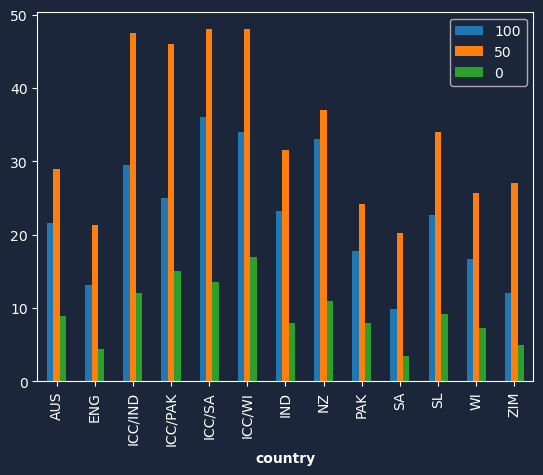

In [99]:
score.plot(kind='bar')

In [100]:
df.head(3)

,player,match,inns,not out,runs,highest strike,average,ball faced,strike rate,100,50,0,4s,6s,start date,end date,country,career length
0,DG Bradman,52,80,10,6996,334,99.94,9800,58.60,29,13,7.0,626,6,1928,1948,AUS,20
1,PHKD Mendis,12,21,2,1184,182,62.31,1839,64.38,5,4,0.0,123,23,2022,2025,SL,3
2,AC Voges,20,31,7,1485,269,61.87,2667,55.68,5,4,2.0,186,5,2015,2016,AUS,1


# visualizeations

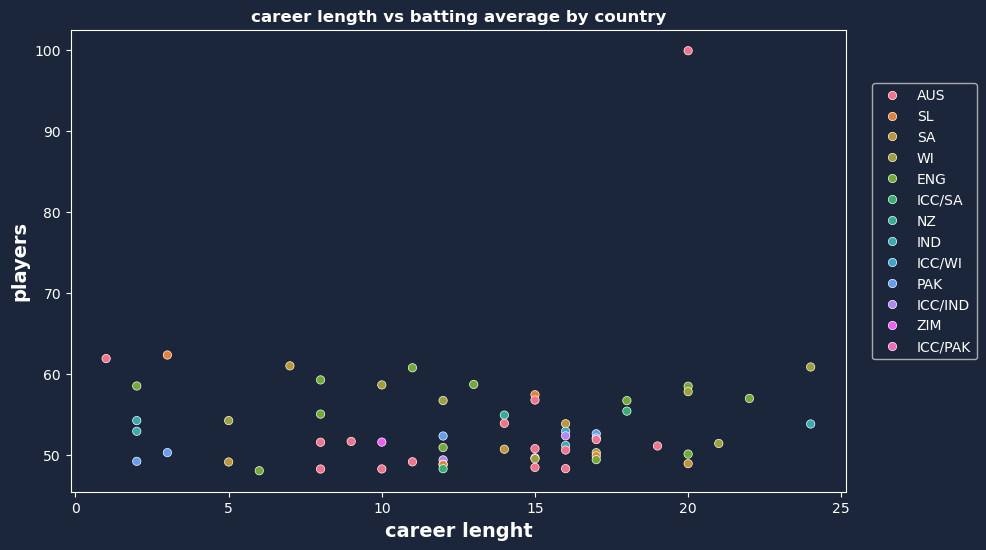

In [101]:
## career lenght vs batting average of country
plt.figure(figsize=(10,6))
sns.scatterplot(data=df,x='career length',y='average',hue="country")
plt.title('career length vs batting average by country')
plt.xlabel('career lenght',fontsize='14',weight='bold')
plt.ylabel('players',fontsize='14',weight='bold')
plt.legend(bbox_to_anchor=(1.025, 0.9),loc='upper left')

C:\Users\ACER\AppData\Local\Temp\ipykernel_10288\4288893477.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.025, 0.9),loc='upper left')


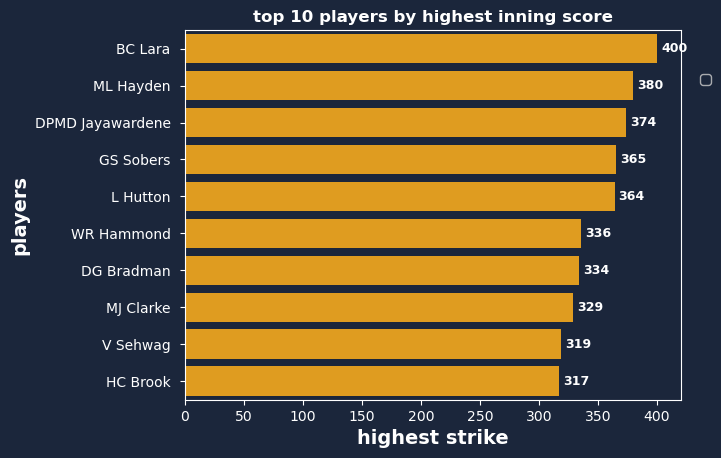

In [109]:
# top 10 highest inning score
top10=df.groupby('highest strike')['player'].max().to_frame().sort_values('highest strike', ascending=False).head(10)
top10

ax=sns.barplot(data=top10,x='highest strike',y='player',color='orange')
for bar in ax.containers:
    ax.bar_label(bar,padding=3,weight='bold',fontsize=9)

#sns.barplot(data=top10,x='highest strike',y='player',color='3EDC531')
plt.title('top 10 players by highest inning score')
plt.xlabel('highest strike',fontsize='14',weight='bold')
plt.ylabel('players',fontsize='14',weight='bold')
plt.legend(bbox_to_anchor=(1.025, 0.9),loc='upper left')


<function matplotlib.pyplot.show(close=None, block=None)>

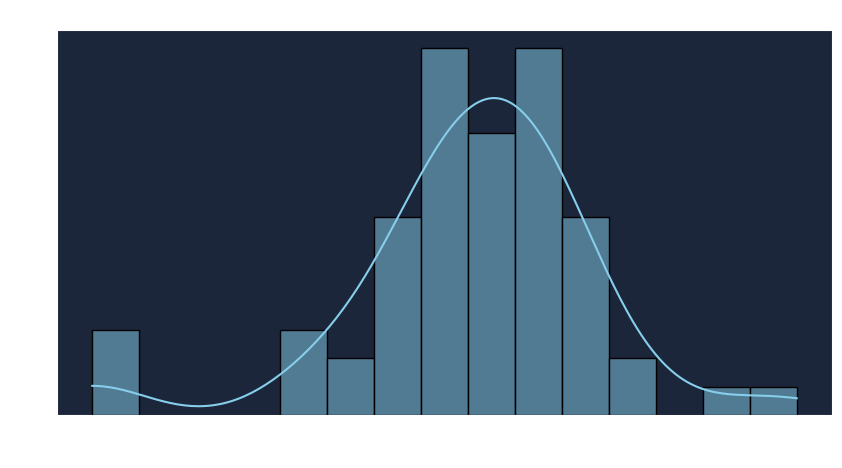

In [30]:
# batting strike rate districbutions

plt.figure(figsize=(10,5),dpi=100)
plt.rcParams.update({
    'figure.facecolor':'#1b263b',
    'axes.facecolor':'#1b263b',
    'axes.edgecolor':'white',
    'axes.labelcolor':'white',
    'xtick.color':'white',
    'ytick.color':'white',
    'text.color':'white',
    'axes.titleweight':'bold',
    'axes.labelweight':'bold'
})
sns.histplot(df['strike rate'],bins=15,color='skyblue',kde=True)
plt.title('batting strike rate frequency')
plt.show

In [31]:
#number of hundreds, fifty and ducks  avg by country
score=df.groupby('country')[['100','50','0']].mean()
score

,100,50,0
country,,,
AUS,21.533333,28.933333,8.933333
ENG,13.076923,21.384615,4.461538
ICC/IND,29.500000,47.500000,12.000000
ICC/PAK,25.000000,46.000000,15.000000
ICC/SA,36.000000,48.000000,13.500000
ICC/WI,34.000000,48.000000,17.000000
IND,23.250000,31.500000,8.000000
NZ,33.000000,37.000000,11.000000
PAK,17.800000,24.200000,8.000000


<Axes: xlabel='country'>

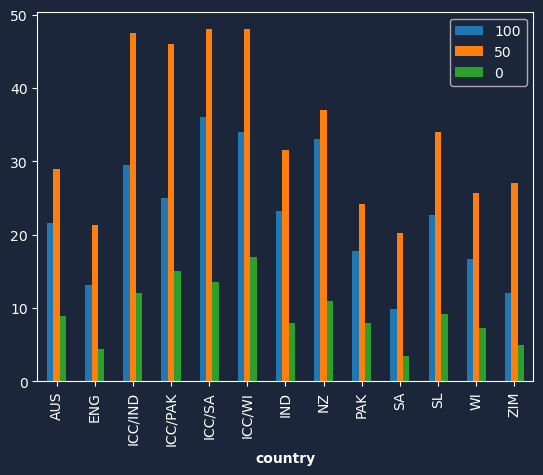

In [32]:
score.plot(kind='bar')

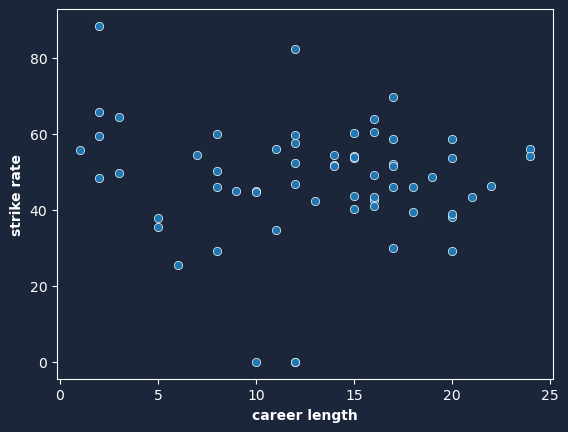

In [103]:
sns.scatterplot(data=df,x='career length',y='strike rate')
plt.title('')
plt.show()

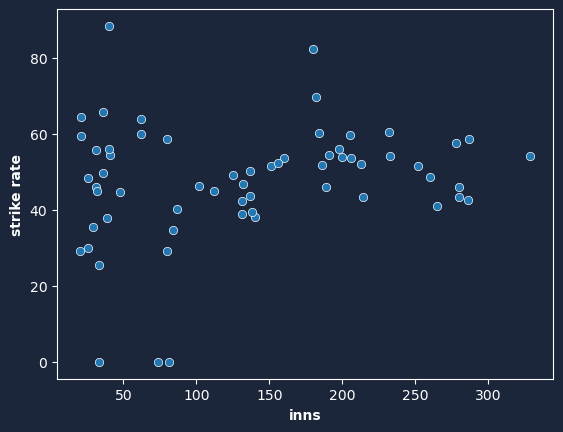

In [34]:
sns.scatterplot(data=df,x='inns',y='strike rate')
plt.title('')
plt.show()

In [35]:
player=df.groupby('player')[['100','50','0']].sum().sort_values(['100','50','0'],ascending=False).head(10)
player

,100,50,0
player,,,
SR Tendulkar,51,68,14.0
JH Kallis,45,58,16.0
RT Ponting,41,62,17.0
KC Sangakkara,38,52,11.0
JE Root,36,65,13.0
R Dravid,36,63,8.0
SPD Smith,36,41,11.0
DPMD Jayawardene,34,50,15.0
BC Lara,34,48,17.0


In [104]:
career=df.groupby('player')['career length'].sum().sort_values(ascending=False)
career

player
GA Headley        24
SR Tendulkar      24
JB Hobbs          22
S Chanderpaul     21
DG Bradman        20
                  ..
Abid Ali           2
VG Kambli          2
HC Brook           2
YBK Jaiswal        2
AC Voges           1
Name: career length, Length: 62, dtype: int64

In [105]:
start=df.groupby('player')['start date'].min()
start

player
A Flower           1992
AB de Villiers     2004
AC Voges           2015
AD Nourse          1935
AR Border          1978
                   ... 
VG Kambli          1993
WH Ponsford        1924
WR Hammond         1927
YBK Jaiswal        2023
Younis Khan        2000
Name: start date, Length: 62, dtype: int64